## A complete data analysis report on the given data.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

In [3]:
path = "Data/datasets_13720_18513_insurance.csv"
df = pd.read_csv(path)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info();df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
shape = df.shape
dtypes = df.dtypes
null_values = df.isnull().sum()
head = df.head()

print("---------------------------\n",shape),
print("---------------------------\n",dtypes),
print("---------------------------\n",null_values),
print("---------------------------\n",head)

---------------------------
 (1338, 7)
---------------------------
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
---------------------------
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
---------------------------
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


##  Categorical Feature Distribution:

(sex
 male      676
 female    662
 Name: count, dtype: int64,
 smoker
 no     1064
 yes     274
 Name: count, dtype: int64,
 region
 southeast    364
 southwest    325
 northwest    325
 northeast    324
 Name: count, dtype: int64)

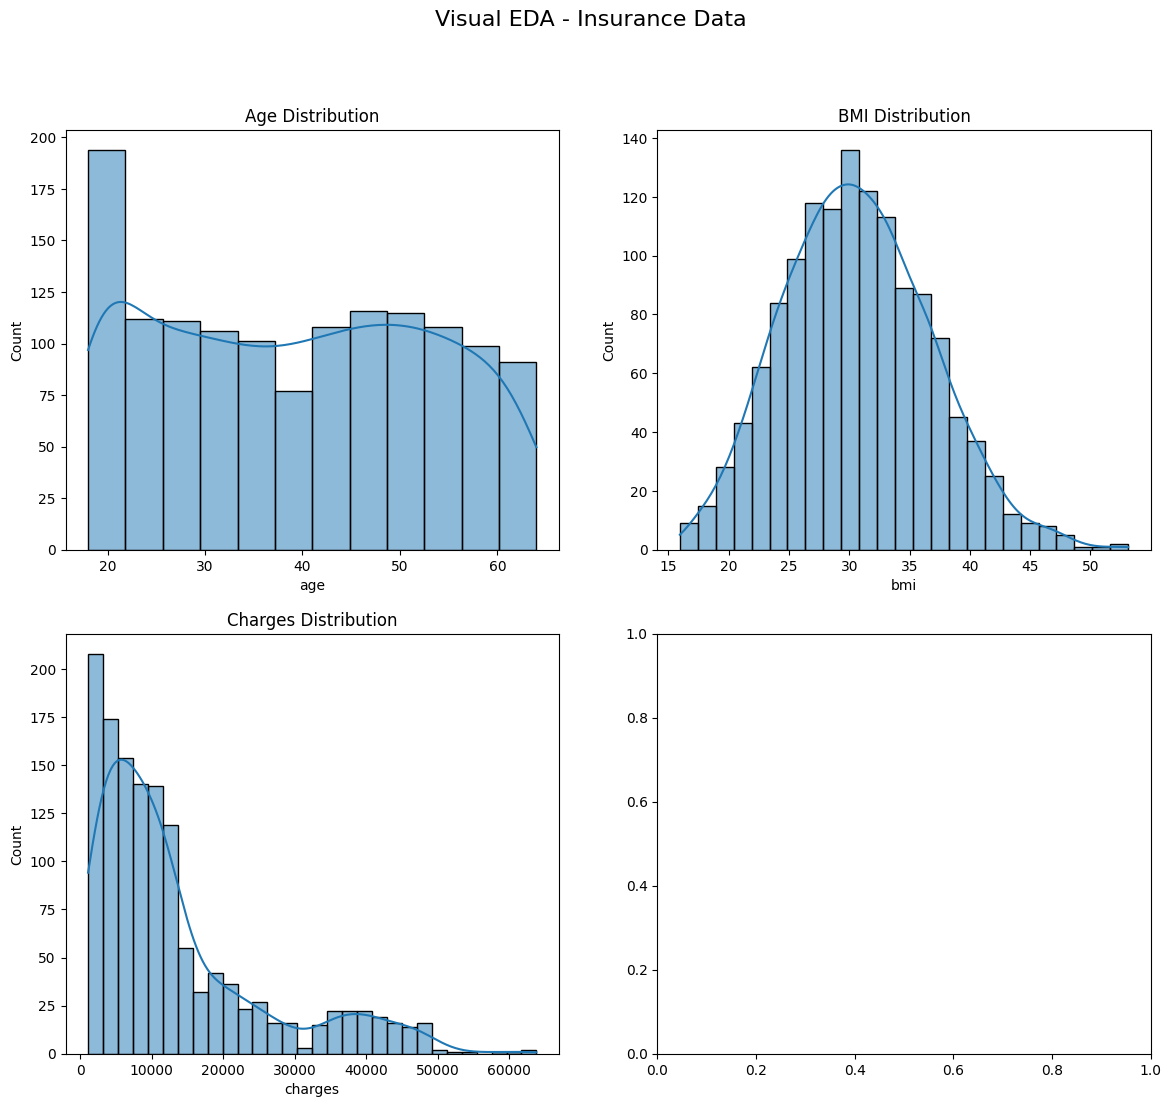

In [6]:
# Value counts for categorical features
sex_counts = df['sex'].value_counts()
smoker_counts = df['smoker'].value_counts()
region_counts = df['region'].value_counts()

# Plotting setup
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Visual EDA - Insurance Data", fontsize=16)

# Age distribution
sns.histplot(df['age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

# BMI distribution
sns.histplot(df['bmi'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("BMI Distribution")

# Charges distribution
sns.histplot(df['charges'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Charges Distribution")

sex_counts, smoker_counts, region_counts


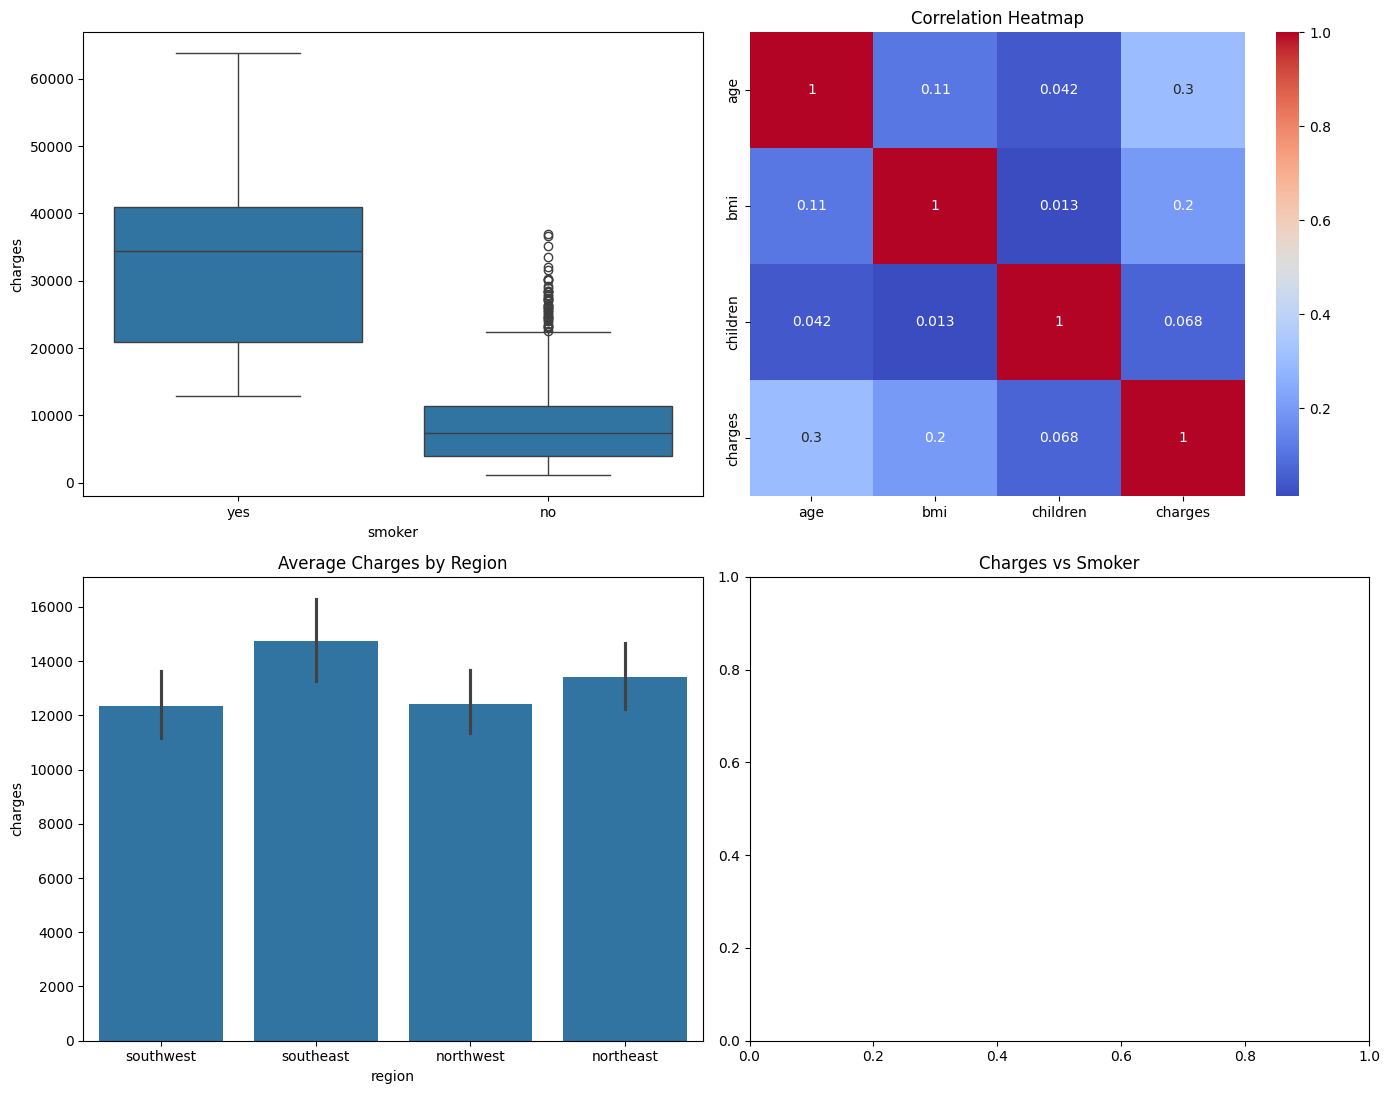

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# Charges vs Smoker
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0, 0])
axes[1, 1].set_title("Charges vs Smoker")

# Charges vs Region
sns.barplot(x='region', y='charges', data=df, estimator=lambda x: sum(x)/len(x), ax=axes[1, 0])
axes[1, 0].set_title("Average Charges by Region")

# Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Correlation Heatmap")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Sex:
Male: 676
Female: 662

Smoker:
No: 1064
Yes: 274

Region:
Southeast: 364
Southwest: 325
Northwest: 325
Northeast: 324

## Visual Insights:
Charges Distribution is right-skewed (few high-cost patients).

Smokers are charged significantly more than non-smokers.

Age and BMI have near-normal distributions.

Region doesn’t majorly affect charges, but Southeast slightly edges others.

Positive correlation exists between:

Age and Charges

BMI and Charges (especially for smokers)

### 1 Prepare the data, identifying and extracting key features (both input and output parameters) relevant to the problem you will solve.
### 2 Build and train a machine learning model. Here you can evaluate different algorithms, settings and see which model is best for your scenario.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,classification_report
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [9]:
X = df.drop("charges", axis=1)
y = df["charges"]
print("-------------X--------------\n",X),print("--------------y-------------\n",y)

-------------X--------------
       age     sex     bmi  children smoker     region
0      19  female  27.900         0    yes  southwest
1      18    male  33.770         1     no  southeast
2      28    male  33.000         3     no  southeast
3      33    male  22.705         0     no  northwest
4      32    male  28.880         0     no  northwest
...   ...     ...     ...       ...    ...        ...
1333   50    male  30.970         3     no  northwest
1334   18  female  31.920         0     no  northeast
1335   18  female  36.850         0     no  southeast
1336   21  female  25.800         0     no  southwest
1337   61  female  29.070         0    yes  northwest

[1338 rows x 6 columns]
--------------y-------------
 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


(None, None)

In [10]:
cat_cols = ["sex", "smoker", "region"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), cat_cols)],
    remainder='passthrough'
)

In [11]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

# Model Evaluation
results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    }

results

{'Linear Regression': {'MAE': 4181.194473753659,
  'RMSE': np.float64(5796.284659276275),
  'R2 Score': 0.7835929767120722},
 'Decision Tree': {'MAE': 3080.9643405447764,
  'RMSE': np.float64(6346.862423347571),
  'R2 Score': 0.7405282334108092},
 'Random Forest': {'MAE': 2554.3777592700917,
  'RMSE': np.float64(4581.114617882647),
  'R2 Score': 0.8648194356210239},
 'Gradient Boosting': {'MAE': 2454.473809214537,
  'RMSE': np.float64(4335.039933716811),
  'R2 Score': 0.8789518532850926},
 'XGBoost': {'MAE': 2851.492234659318,
  'RMSE': np.float64(4898.202405569293),
  'R2 Score': 0.8454584035864013}}

In [12]:
best_model = max(results, key=lambda x: results[x]["R2 Score"])
best_model,r2_score(y_test, y_pred)

('Gradient Boosting', 0.8454584035864013)

##  Best Model: Gradient Boosting

In [13]:
from sklearn.model_selection import RandomizedSearchCV
# Create the random grid
random_grid = { 'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7, 10],
                'model__subsample': [0.6, 0.8, 1.0],
                'model__colsample_bytree': [0.6, 0.8, 1.0]}
gb_random = RandomizedSearchCV(estimator = pipe, 
                               param_distributions = random_grid,scoring='r2', 
                               n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = 1)
gb_random

E:\Projects\DATASCIENCE & AI\Internship Projects\PRCP-1021-InsCostPred\9-4-2025\.InsCP\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['sex',
                                                                                'smoker',
                                                                                'region'])])),
                                             ('model',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rou...
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=100,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7, 10],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [14]:
gb_random.fit(X_train,y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=7, model__n_estimators=300, model__subsample=0.6; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=7, model__n_estimators=300, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=7, model__n_estimators=300, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=7, model__n_estimators=300, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=7, model__n_estimators=300, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.6; total time=   0.0s
[CV] END model__colsample_bytree=

E:\Projects\DATASCIENCE & AI\Internship Projects\PRCP-1021-InsCostPred\9-4-2025\.InsCP\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['sex',
                                                                                'smoker',
                                                                                'region'])])),
                                             ('model',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rou...
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=100,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7, 10],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [15]:
prediction = gb_random.predict(X_test)
prediction

array([10841.285 ,  6410.286 , 27157.697 , 10270.771 , 33915.61  ,
        6361.055 ,  3616.824 , 14737.439 ,  5389.041 , 11203.394 ,
       18682.205 ,  8157.811 ,  5232.225 , 45068.387 , 47042.6   ,
       44792.043 , 11576.678 , 43591.566 ,  9966.114 , 23114.158 ,
        6296.294 ,  8953.385 ,  2819.5886,  4112.6533, 11714.458 ,
       12474.61  , 14745.251 ,  7193.552 , 11215.669 ,  2800.7954,
        8057.116 , 12349.995 ,  3547.0273,  6657.325 ,  4725.2373,
        9371.436 ,  3848.0986,  8826.754 , 24477.232 , 40457.05  ,
        6263.869 ,  4385.7573, 13295.213 , 14129.803 ,  8086.445 ,
       15463.186 ,  6827.3154,  6213.783 , 42675.496 ,  7274.17  ,
       14993.344 ,  2814.261 ,  7709.9243,  2674.6155, 12368.809 ,
       11500.431 ,  5101.099 , 40474.113 , 12414.112 , 12562.466 ,
       14724.468 ,  7028.6   , 17225.986 ,  8883.684 , 11846.618 ,
        6071.658 , 19297.299 , 12458.459 ,  6126.614 ,  3552.0742,
        7730.248 , 10926.476 , 10425.12  ,  7868.068 ,  9370.8

In [16]:
print('MAE:', mean_absolute_error(y_test, prediction))
print('MSE:', mean_squared_error(y_test, prediction))
print('RMSE:', np.sqrt(mean_squared_error(y_test, prediction)))

MAE: 2492.0476218741837
MSE: 18461660.710066758
RMSE: 4296.703470111332


In [17]:
df_bk= df.copy()
out=pd.DataFrame({'Price_actual':y_test,'Price_pred':y_pred})
result=df_bk.merge(out,left_index=True,right_index=True)
result.sample(10)

,age,sex,bmi,children,smoker,region,charges,Price_actual,Price_pred
244,63,female,27.740,0,yes,northeast,29523.16560,29523.16560,27972.585938
51,21,female,33.630,2,no,northwest,3579.82870,3579.82870,20398.003906
661,57,female,23.980,1,no,southeast,22192.43711,22192.43711,10583.038086
438,52,female,46.750,5,no,southeast,12592.53450,12592.53450,16176.276367
817,23,male,37.100,3,no,southwest,3597.59600,3597.59600,2429.877441
777,45,male,39.805,0,no,northeast,7448.40395,7448.40395,11123.497070
428,21,female,16.815,1,no,northeast,3167.45585,3167.45585,3781.519775
1286,28,female,17.290,0,no,northeast,3732.62510,3732.62510,7163.946777
237,31,male,38.390,2,no,southeast,4463.20510,4463.20510,7218.199219
464,19,male,25.175,0,no,northwest,1632.03625,1632.03625,1048.530396


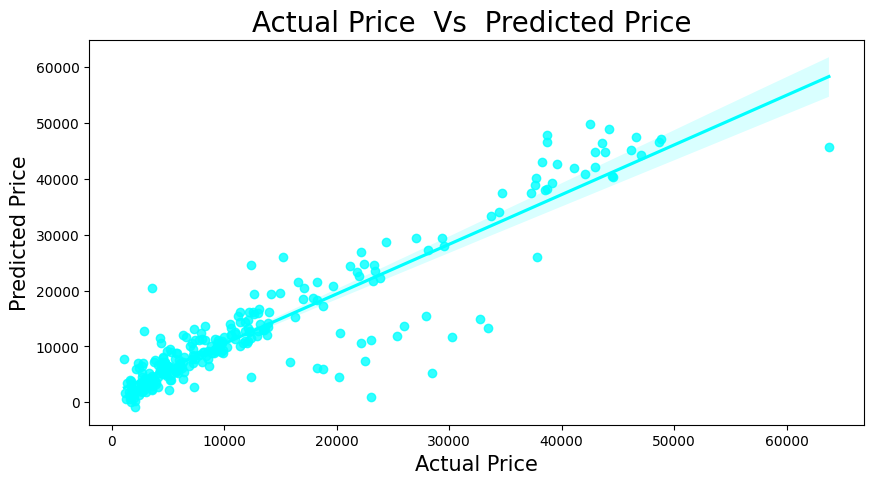

In [18]:
plt.figure(figsize=(10,5))
sns.regplot(x='Price_actual',y='Price_pred',data=result,color='cyan')
plt.title('Actual Price  Vs  Predicted Price ',fontsize=20)
plt.xlabel('Actual Price',fontsize=15)
plt.ylabel('Predicted Price',fontsize=15)
plt.show()

In [19]:
pd.set_option('display.max.rows',None)
result.head(15)

,age,sex,bmi,children,smoker,region,charges,Price_actual,Price_pred
23,34,female,31.920,1,yes,northeast,37701.87680,37701.87680,40122.792969
29,31,male,36.300,2,yes,southwest,38711.00000,38711.00000,46642.878906
31,18,female,26.315,0,no,northeast,2198.18985,2198.18985,1822.252197
32,19,female,28.600,5,no,southwest,4687.79700,4687.79700,6297.638184
43,37,female,30.800,2,no,southeast,6313.75900,6313.75900,7159.416992
44,38,male,37.050,1,no,northeast,6079.67150,6079.67150,6712.580078
48,60,female,24.530,0,no,southeast,12629.89670,12629.89670,19332.888672
49,36,male,35.200,1,yes,southeast,38709.17600,38709.17600,38217.792969
51,21,female,33.630,2,no,northwest,3579.82870,3579.82870,20398.003906
54,40,female,28.690,3,no,northwest,8059.67910,8059.67910,7205.662598


In [20]:
import joblib

joblib.dump(gb_random.best_estimator_, 'insurancecostpred.pkl')


['insurancecostpred.pkl']

In [21]:
# Example input
new_customer = pd.DataFrame({
    'age': [34],
    'sex': ['female'],
    'bmi': [31.9],
    'children': [1],
    'smoker': ['yes'],
    'region': ['northeast']
})
print(new_customer,"\n")
model = joblib.load('insurancecostpred.pkl')
prediction = model.predict(new_customer)
print("Predicted Insurance Cost: ₹", round(prediction[0], 2))


   age     sex   bmi  children smoker     region
0   34  female  31.9         1    yes  northeast 

Predicted Insurance Cost: ₹ 39258.0
